# PERSIAPAN

## Import library

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import logging
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv3D, MaxPooling3D,
                                     Flatten, Dense, Dropout, BatchNormalization, concatenate,
                                     GlobalAveragePooling2D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import (MobileNetV2, EfficientNetB0, ResNet50)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

2025-07-15 12:03:16.429712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752580996.808437      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752580996.912265      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Membuat fungsi utilitas logging

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    handlers=[
        logging.FileHandler("log_preprocessing_dataset.log", mode='w'), # Simpan log ke file
        logging.StreamHandler() # Tampilkan juga di layar
    ]
)

# Dapatkan instance logger untuk digunakan di seluruh skrip
logger = logging.getLogger(__name__)

logger.info("Sistem logging siap digunakan.")

## Membuat nama lead

In [3]:
lead_names = [
    'lead_I', 'lead_II', 'lead_III',
    'lead_aVR', 'lead_aVL', 'lead_aVF',
    'lead_V1', 'lead_V2', 'lead_V3',
    'lead_V4', 'lead_V5', 'lead_V6'
]

## Membuat folder output

In [4]:
def create_output_directory():
    # --- LANGKAH 1: DEFINISIKAN SEMUA NAMA FOLDER ---

    # Definisikan nama folder paling atas (root)
    folder_utama = 'data_preprocess'
    
    # Definisikan nama-nama subfolder level 1
    subfolder_utama = ['01_gray', '02_blur', '03_thres', '04_clean', '05_lead']
    
    # Definisikan nama-nama subfolder di dalam '05_lead'
    subfolder_di_dalam_lead = ['01_long', '02_short']
    
    # Definisikan nama-nama untuk 12 lead
    nama_12_lead = list(lead_names)
    
    # --- LANGKAH 2: BUAT STRUKTUR FOLDER SECARA BERTAHAP ---
    
    logger.info(f"Membuat folder utama: '{folder_utama}'")
    os.makedirs(folder_utama, exist_ok=True) # Membuat folder utama
    
    # Membuat subfolder level 1 di dalam folder_utama
    logger.info("Membuat subfolder level 1...")
    for sub in subfolder_utama:
        path = os.path.join(folder_utama, sub)
        os.makedirs(path, exist_ok=True)
    
    # Membuat subfolder level 2 di dalam '05_lead'
    logger.info("Membuat subfolder di dalam '05_lead'...")
    path_folder_lead = os.path.join(folder_utama, '05_lead')
    for sub in subfolder_di_dalam_lead:
        path = os.path.join(path_folder_lead, sub)
        os.makedirs(path, exist_ok=True)
        
    # Membuat 12 folder lead di dalam '02_short' (level 3)
    logger.info("Membuat 12 folder lead...")
    path_folder_short = os.path.join(path_folder_lead, '02_short')
    for nama_lead in nama_12_lead:
        path = os.path.join(path_folder_short, nama_lead)
        os.makedirs(path, exist_ok=True)
    
    logger.info("\n✅ Struktur folder telah berhasil dibuat!")

In [5]:
create_output_directory()

# Langkah 1: Proses dataset

## Membuat fungsi proses satu gambar ekg

In [6]:
def preprocess_single_ecg_triple_output(image_path):
    try:
        gambar_asli = cv2.imread(image_path)
        nama_file = os.path.basename(image_path)
        if gambar_asli is None:
            print(f"  - Gagal memuat gambar: {image_path}")
            return None, None, None
        
        # --- Tahap 1 & 2: Preprocessing dan Pembersihan ---
        gambar_gray = cv2.cvtColor(gambar_asli, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(os.path.join('data_preprocess/01_gray', nama_file), gambar_gray)
        
        gambar_blurred = cv2.GaussianBlur(gambar_gray, (5, 5), 0)
        cv2.imwrite(os.path.join('data_preprocess/02_blur', nama_file), gambar_blurred)
        
        ret, gambar_thresholded = cv2.threshold(gambar_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        cv2.imwrite(os.path.join('data_preprocess/03_thres', nama_file), gambar_thresholded)
        
        kernel = np.ones((3,3), np.uint8)
        gambar_cleaned = cv2.morphologyEx(gambar_thresholded, cv2.MORPH_OPEN, kernel)
        cv2.imwrite(os.path.join('data_preprocess/04_clean', nama_file), gambar_cleaned)
        
        # --- Tahap 3: Deteksi Kontur Blok Sinyal ---
        contours, _ = cv2.findContours(gambar_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        kontur_valid = []
        area_minimum = 5000
        for c in contours:
            if cv2.contourArea(c) > area_minimum:
                kontur_valid.append((c, cv2.boundingRect(c)))
        
        if len(kontur_valid) < 1:
            print(f"  - Tidak ditemukan kontur blok sinyal utama pada: {image_path}")
            return None, None, None
        
        # --- Tahap 4: Crop Blok Sinyal Utama (Terbesar) ---
        kontur_terbesar, bbox_terbesar = max(kontur_valid, key=lambda item: cv2.contourArea(item[0]))
        kontur_terbawah, bbox_terbawah = max(kontur_valid, key=lambda item: item[1][1])
        
        padding_x = 5
        padding_y = 0
        
        # Crop 12 lead
        (x, y, w, h) = bbox_terbesar
        crop_12_lead_cleaned = gambar_cleaned[y-padding_y : y+h+padding_y, x-padding_x : x+w+padding_x]
        # print(crop_12_lead_cleaned)
        
        # Crop long lead
        (x, y, w, h) = bbox_terbawah
        crop_long_lead_cleaned = gambar_cleaned[y-padding_y : y+h+padding_y, x-padding_x : x+w+padding_x]

        UKURAN_STANDAR_BLOK = (1980, 786)
    
        # print(f"  - Ukuran blok 12-lead asli: {crop_12_lead_cleaned.shape[1]}x{crop_12_lead_cleaned.shape[0]}")
        crop_12_lead_standardized = cv2.resize(crop_12_lead_cleaned, UKURAN_STANDAR_BLOK, interpolation=cv2.INTER_AREA)
        # print(f"  - Ukuran blok 12-lead setelah distandarisasi: {crop_12_lead_standardized.shape[1]}x{crop_12_lead_standardized.shape[0]}")
        
        # --- Tahap 5: Pemisahan 12-Lead Manual ---
        # Format: [ (x1, y1, x2, y2), ... ] untuk setiap lead
        min_gap = 487
        kolom_mulai_x = [6, 502, 993, 1485]
        kolom_akhir_x = [kolom_mulai_x[0] + min_gap,
                          kolom_mulai_x[1] + min_gap,
                          kolom_mulai_x[2] + min_gap,
                          kolom_mulai_x[3] + min_gap]
        
        koordinat_leads = [
            # Kolom 1
            (kolom_mulai_x[0], 0, kolom_akhir_x[0], 262),  # Koordinat untuk Lead I
            (kolom_mulai_x[0], 262, kolom_akhir_x[0], 524),  # Koordinat untuk Lead II
            (kolom_mulai_x[0], 524, kolom_akhir_x[0], 786),  # Koordinat untuk Lead III
            # Kolom 2
            (kolom_mulai_x[1], 0, kolom_akhir_x[1], 262),  # Koordinat untuk Lead aVR
            (kolom_mulai_x[1], 262, kolom_akhir_x[1], 524), # Koordinat untuk Lead aVL
            (kolom_mulai_x[1], 524, kolom_akhir_x[1], 786), # Koordinat untuk Lead aVF
            # Kolom 3
            (kolom_mulai_x[2], 0, kolom_akhir_x[2], 262),  # Koordinat untuk Lead V1
            (kolom_mulai_x[2], 262, kolom_akhir_x[2], 524), # Koordinat untuk Lead V2
            (kolom_mulai_x[2], 524, kolom_akhir_x[2], 786), # Koordinat untuk Lead V3
            # Kolom 4
            (kolom_mulai_x[3], 0, kolom_akhir_x[3], 262), # Koordinat untuk Lead V4
            (kolom_mulai_x[3], 262, kolom_akhir_x[3], 524),# Koordinat untuk Lead V5
            (kolom_mulai_x[3], 524, kolom_akhir_x[3], 786) # Koordinat untuk Lead V6
        ]
        
        # Urutan pemisahan yang disesuaikan dengan layout EKG
        urutan_layout = [
            (0,0), (1,0), (2,0), # Kolom 1
            (0,1), (1,1), (2,1), # Kolom 2
            (0,2), (1,2), (2,2), # Kolom 3
            (0,3), (1,3), (2,3)  # Kolom 4
        ]
        
        list_hasil_manual = []
        for (baris, kolom) in urutan_layout:
            idx = baris * 4 + kolom
            (x1, y1, x2, y2) = koordinat_leads[idx]
            potongan = crop_12_lead_standardized[y1:y2, x1:x2]
            list_hasil_manual.append(potongan)
        
        UKURAN_TARGET_12_LEAD = (224, 144) # (lebar, tinggi)
        nama_12_lead = list(lead_names)
        list_12_lead_resized = []
        folder_tujuan_12_leads = os.path.join('data_preprocess', '05_lead', '02_short')
        folder_tujuan_long_lead = os.path.join('data_preprocess', '05_lead', '01_long')
        # print(f"Hasil resize setiap lead akan disimpan di: '{folder_tujuan_leads}'")

        for i, potongan in enumerate(list_hasil_manual):
    
            # 1. Lakukan resize
            potongan_resized = cv2.resize(potongan, UKURAN_TARGET_12_LEAD, interpolation=cv2.INTER_AREA)
            
            # 2. Tambahkan hasil resize ke dalam list
            list_12_lead_resized.append(potongan_resized)
            
            # 3. Buat nama file yang unik untuk setiap lead
            folder_tujuan_lengkap = os.path.join(folder_tujuan_12_leads, nama_12_lead[i])
            nama_file_output = f"{nama_file}"
            
            # 4. Bangun path lengkap
            path_lengkap_output = os.path.join(folder_tujuan_lengkap, nama_file_output)
            
            # 5. Simpan gambar yang sudah di-resize
            cv2.imwrite(path_lengkap_output, potongan_resized)
        
        # print(f"\n{len(list_12_lead_resized)} gambar lead telah di-resize dan disimpan.")
        
        limb_leads_resized = list_12_lead_resized[0:6]      # Ambil 6 pertama untuk Limb
        precordial_leads_resized = list_12_lead_resized[6:12] # Ambil 6 terakhir untuk Precordial

        # PERUBAHAN 2: Lakukan stacking secara terpisah
        if len(limb_leads_resized) != 6 or len(precordial_leads_resized) != 6:
            # logger.warning(f"Gagal memisahkan 6 limb dan 6 precordial leads pada: {os.path.basename(image_path)}")
            return None, None, None
            
        volume_limb = np.stack(limb_leads_resized, axis=0)
        volume_precordial = np.stack(precordial_leads_resized, axis=0)
        
        # --- Tahap 5B: Proses Long-Lead ---
        UKURAN_TARGET_LONG_LEAD = (898, 141) # (lebar, tinggi)
        long_lead_resized = cv2.resize(crop_long_lead_cleaned, UKURAN_TARGET_LONG_LEAD, interpolation=cv2.INTER_AREA)
        path_lengkap_long = os.path.join(folder_tujuan_long_lead, f'{nama_file}')
        cv2.imwrite(path_lengkap_long, long_lead_resized)
        
        return volume_limb, volume_precordial, long_lead_resized

    except Exception as e:
        # print(f"  - Terjadi error saat memproses {image_path}: {e}")
        return None, None, None

## Membuat proses batch

In [7]:
path_dataset_utama = "/kaggle/input/dataset-6plus6plus1"
X_limb_data = []
X_precordial_data = []
X_long_lead_data = []
y_labels = []

if not os.path.exists(path_dataset_utama):
    print(f"Error: Direktori '{path_dataset_utama}' tidak ditemukan.")
else:
    for nama_kategori in sorted(os.listdir(path_dataset_utama)):
        path_kategori = os.path.join(path_dataset_utama, nama_kategori)
        if os.path.isdir(path_kategori):
            print(f"\nMemproses kategori: '{nama_kategori}'...")
            for nama_file in os.listdir(path_kategori):
                path_file_gambar = os.path.join(path_kategori, nama_file)
        
                # Panggil fungsi yang mengembalikan tiga nilai
                hasil_proses = preprocess_single_ecg_triple_output(path_file_gambar)
                
                # Unpacking yang aman
                if hasil_proses and all(item is not None for item in hasil_proses):
                    # Bongkar tiga nilai jika pemrosesan berhasil
                    volume_limb, volume_precordial, long_lead = hasil_proses
                    
                    # Masukkan setiap data ke listnya masing-masing
                    X_limb_data.append(volume_limb)
                    X_precordial_data.append(volume_precordial)
                    X_long_lead_data.append(long_lead)
                    y_labels.append(nama_kategori)
                    
                    # print(f"  - Berhasil memproses: {nama_file}")
    
    print("\n=====================================")
    print("SELURUH DATASET TELAH SELESAI DIPROSES.")
    print(f"Total gambar yang berhasil diproses: {len(y_labels)}")
    print("=====================================")

# --- TAHAP FINAL: KONVERSI & SIMPAN TIGA FILE .NPY TERPISAH ---
if y_labels:
    
    # Konversi dan simpan data Limb-Lead (volume)
    X_limb_final = np.array(X_limb_data)
    np.save('X_limb_processed.npy', X_limb_final)
    print(f"\nData Limb-Lead (volume) disimpan ke 'X_limb_processed.npy'")
    print(f"Bentuk (shape) data: {X_limb_final.shape}")
    
    # Konversi dan simpan data Precordial-Lead (volume)
    X_precordial_final = np.array(X_precordial_data)
    np.save('X_precordial_processed.npy', X_precordial_final)
    print(f"\nData Precordial-Lead (volume) disimpan ke 'X_precordial_processed.npy'")
    print(f"Bentuk (shape) data: {X_precordial_final.shape}")
    
    # Konversi dan simpan data long-lead
    X_long_lead_final = np.array(X_long_lead_data)
    np.save('X_long_lead_processed.npy', X_long_lead_final)
    print(f"\nData Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'")
    print(f"Bentuk (shape) data: {X_long_lead_final.shape}")
    
    # Konversi dan simpan label (cukup satu kali karena sama untuk semuanya)
    y_final = np.array(y_labels)
    np.save('y_labels.npy', y_final)
    print(f"\nLabel disimpan ke 'y_labels.npy'")
    print(f"Bentuk (shape) data: {y_final.shape}")


Memproses kategori: 'abnormal'...

Memproses kategori: 'history_myocardial_infaction'...

Memproses kategori: 'myocardial_infarction'...

Memproses kategori: 'normal'...

SELURUH DATASET TELAH SELESAI DIPROSES.
Total gambar yang berhasil diproses: 928

Data Limb-Lead (volume) disimpan ke 'X_limb_processed.npy'
Bentuk (shape) data: (928, 6, 144, 224)

Data Precordial-Lead (volume) disimpan ke 'X_precordial_processed.npy'
Bentuk (shape) data: (928, 6, 144, 224)

Data Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'
Bentuk (shape) data: (928, 141, 898)

Label disimpan ke 'y_labels.npy'
Bentuk (shape) data: (928,)


## Load data gambar yang sudah diproses

In [8]:
def load_triple_input_dataset(path_limb, path_precordial, path_long, path_y):
    print("Memuat 3 set data input yang sudah diproses...")
    try:
        X_limb = np.load(path_limb)
        X_precordial = np.load(path_precordial)
        X_long = np.load(path_long)
        y_str = np.load(path_y)
        
    except FileNotFoundError:
        print(f"Error: Salah satu atau lebih file tidak ditemukan. Periksa kembali path file.")
        return None, None, None, None, None, None
    else:
        print("Data berhasil dimuat.")
        print(f"Bentuk X_limb: {X_limb.shape}")
        print(f"Bentuk X_precordial: {X_precordial.shape}")
        print(f"Bentuk X_long: {X_long.shape}")
        print(f"Bentuk y_str: {y_str.shape}")
        
        # --- ENCODING LABEL ---
        print("\nMelakukan encoding pada label...")
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y_str)
        num_classes = len(encoder.classes_)
        
        print(f"Jumlah kelas: {num_classes}")
        print("Pemetaan Label:")
        for i, kelas in enumerate(encoder.classes_):
            print(f"- {kelas} -> {i}")
            
        return X_limb, X_precordial, X_long, y_encoded, num_classes, encoder

## Membagi dataset untuk data latih, validasi, dan tes

In [9]:
path_limb = 'X_limb_processed.npy'
path_precordial = 'X_precordial_processed.npy'
path_long = 'X_long_lead_processed.npy'
path_label = 'y_labels.npy'

X_limb, X_precordial, X_long, y, NUM_CLASSES, encoder = load_triple_input_dataset(
    path_limb, 
    path_precordial,
    path_long, 
    path_label
)

Memuat 3 set data input yang sudah diproses...
Data berhasil dimuat.
Bentuk X_limb: (928, 6, 144, 224)
Bentuk X_precordial: (928, 6, 144, 224)
Bentuk X_long: (928, 141, 898)
Bentuk y_str: (928,)

Melakukan encoding pada label...
Jumlah kelas: 4
Pemetaan Label:
- abnormal -> 0
- history_myocardial_infaction -> 1
- myocardial_infarction -> 2
- normal -> 3


In [10]:
def pembagian_data(*X_arrays, y, test_size=0.20, val_size=0.20, random_state=42):
    # Dapatkan jumlah total sampel
    num_samples = len(y)
    # Buat array berisi semua indeks dari 0 sampai N-1
    indices = np.arange(num_samples)

    # Tahap 1: Pisahkan indeks menjadi train_pool dan test
    train_val_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Ambil label untuk train_pool untuk stratifikasi selanjutnya
    y_train_val = y[train_val_indices]
    
    # Tahap 2: Pisahkan indeks train_pool menjadi train final dan validation
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=val_size,
        random_state=random_state,
        stratify=y_train_val
    )

    # Sekarang kita punya 3 set indeks: train_indices, val_indices, test_indices
    
    # Gunakan indeks ini untuk memotong semua array X
    X_trains = [X[train_indices] for X in X_arrays]
    X_vals = [X[val_indices] for X in X_arrays]
    X_tests = [X[test_indices] for X in X_arrays]
    
    # Gunakan indeks untuk memotong array y
    y_train = y[train_indices]
    y_val = y[val_indices]
    y_test = y[test_indices]
    
    # Kembalikan semua bagian dalam bentuk list untuk X dan array untuk y
    return X_trains, X_vals, X_tests, y_train, y_val, y_test

In [11]:
def reshape_multidata_for_2d_model(list_of_x_arrays):
    print(f"Mereshape {len(list_of_x_arrays)} set data...")
    
    reshaped_list = []
    for i, data in enumerate(list_of_x_arrays):
        # Jika data memiliki 4 dimensi (seperti volume 12-lead atau 6-lead)
        if data.ndim == 4:
            print(f"  - Mentranspose data ke-{i+1} dari {data.shape}...")
            reshaped_data = data.transpose(0, 2, 3, 1)
            reshaped_list.append(reshaped_data)
            print(f"    -> Bentuk baru: {reshaped_data.shape}")
        # Jika data memiliki 3 dimensi (seperti long-lead)
        elif data.ndim == 3:
            print(f"  - Menambah dimensi channel pada data ke-{i+1} dari {data.shape}...")
            reshaped_data = np.expand_dims(data, axis=-1)
            reshaped_list.append(reshaped_data)
            print(f"    -> Bentuk baru: {reshaped_data.shape}")
        else:
            print(f"  - Data ke-{i+1} sudah memiliki dimensi yang benar atau tidak dikenali. Dilewati.")
            reshaped_list.append(data)
            
    return reshaped_list

In [12]:
X_train_list, X_val_list, X_test_list, \
y_train, y_val, y_test = pembagian_data(
                                X_limb, 
                                X_precordial, 
                                X_long, 
                                y=y,
                                test_size=0.20,
                                val_size=0.25 # 25% dari 80% -> 20% dari total
                            )

# # --- Verifikasi Hasil Akhir ---
print("\n--- UKURAN DATASET SETELAH DIBAGI ---")
print(f"Jumlah set X untuk training: {len(X_train_list)}")
print(f"  - Bentuk X_limb_train: {X_train_list[0].shape}")
print(f"  - Bentuk X_precordial_train: {X_train_list[1].shape}")
print(f"  - Bentuk X_long_train: {X_train_list[2].shape}")
print(f"Bentuk y_train: {y_train.shape}")
print("-" * 20)
print(f"Jumlah sampel validasi: {len(y_val)}")
print(f"Jumlah sampel tes: {len(y_test)}")

# # Jangan lupa menambahkan dimensi channel untuk input CNN jika belum
# X_12_train = np.expand_dims(X_12_train, axis=-1)
# X_12_val = np.expand_dims(X_12_val, axis=-1)
# X_12_test = np.expand_dims(X_12_test, axis=-1)

# X_long_train = np.expand_dims(X_long_train, axis=-1)
# X_long_val = np.expand_dims(X_long_val, axis=-1)
# X_long_test = np.expand_dims(X_long_test, axis=-1)

# --- LANGKAH 4 (KRUSIAL): MENYIAPKAN BENTUK DATA UNTUK MODEL 2D ---
# Pastikan Anda menjalankan blok ini dengan benar!

print("\n--- Mereshape Data Training ---")
X_train_reshaped = reshape_multidata_for_2d_model(X_train_list)

print("\n--- Mereshape Data Validasi ---")
X_val_reshaped = reshape_multidata_for_2d_model(X_val_list)

print("\n--- Mereshape Data Tes ---")
X_test_reshaped = reshape_multidata_for_2d_model(X_test_list)

print("\nSemua data telah berhasil di-reshape dan siap untuk model.")


--- UKURAN DATASET SETELAH DIBAGI ---
Jumlah set X untuk training: 3
  - Bentuk X_limb_train: (556, 6, 144, 224)
  - Bentuk X_precordial_train: (556, 6, 144, 224)
  - Bentuk X_long_train: (556, 141, 898)
Bentuk y_train: (556,)
--------------------
Jumlah sampel validasi: 186
Jumlah sampel tes: 186

--- Mereshape Data Training ---
Mereshape 3 set data...
  - Mentranspose data ke-1 dari (556, 6, 144, 224)...
    -> Bentuk baru: (556, 144, 224, 6)
  - Mentranspose data ke-2 dari (556, 6, 144, 224)...
    -> Bentuk baru: (556, 144, 224, 6)
  - Menambah dimensi channel pada data ke-3 dari (556, 141, 898)...
    -> Bentuk baru: (556, 141, 898, 1)

--- Mereshape Data Validasi ---
Mereshape 3 set data...
  - Mentranspose data ke-1 dari (186, 6, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 6)
  - Mentranspose data ke-2 dari (186, 6, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 6)
  - Menambah dimensi channel pada data ke-3 dari (186, 141, 898)...
    -> Bentuk baru: (186, 141, 898, 1)


# Langkah 2: Membuat model

## Membuat satu fungsi untuk menggunakan salah satu model yang sudah tersedia

In [13]:
def create_flexible_transfer_model(list_of_input_shapes, num_classes, model_name='MobileNetV2'):
    
    model_inputs = []         # Untuk menampung semua layer Input
    branch_feature_outputs = [] # Untuk menampung output fitur dari setiap cabang

    # Dictionary untuk memilih model dasar
    base_models = {
        'MobileNetV2': MobileNetV2,
        'EfficientNetB0': EfficientNetB0,
        'ResNet50': ResNet50
    }
    
    # --- Loop untuk membuat setiap cabang secara dinamis ---
    for i, input_shape in enumerate(list_of_input_shapes):
        # 1. Buat layer Input untuk cabang ini
        current_input = Input(shape=input_shape, name=f'input_branch_{i+1}')
        model_inputs.append(current_input)
        
        # 2. Lapisan Adaptasi (mengubah channel input menjadi 3)
        adapter = Conv2D(3, (1, 1), padding='same', activation='relu', name=f'adapter_branch_{i+1}')(current_input)
        
        # 3. Buat instance model dasar dengan nama unik
        Base_Model_Class = base_models[model_name]
        base_model = Base_Model_Class(
            input_shape=input_shape[:2] + (3,), 
            include_top=False, 
            weights='imagenet',
            name=f'base_model_branch_{i+1}' # Nama unik untuk setiap cabang
        )
        base_model.trainable = False
        
        # 4. Proses input melalui cabang
        features = base_model(adapter, training=False)
        features = GlobalAveragePooling2D(name=f'gap_branch_{i+1}')(features)
        branch_feature_outputs.append(features)

    # --- Penggabungan (Merge) ---
    # Jika ada lebih dari satu cabang, gabungkan. Jika tidak, gunakan saja output tunggal.
    if len(branch_feature_outputs) > 1:
        gabungan = concatenate(branch_feature_outputs, name='concatenate_features')
    else:
        gabungan = branch_feature_outputs[0]
        
    # --- Kepala Klasifikasi ---
    x = Dense(256, activation='relu')(gabungan)
    x = Dropout(0.5)(x)
    output_final = Dense(num_classes, activation='softmax')(x)
    
    # --- Buat Model Final ---
    # `inputs` sekarang adalah list dari semua layer Input yang kita buat
    model = Model(inputs=model_inputs, outputs=output_final)
    
    return model

## Menyiapkan input yang akan digunakan model

In [14]:
# Dapatkan bentuk input dari data yang sudah di-reshape
list_of_shapes = [data.shape[1:] for data in X_train_reshaped]

# Langkah 3: Melatih Model

## Melatih model MobileNetV2

### Membuat model dan debug isi model

In [15]:
# Pilih model Anda, misalnya 'MobileNetV2'
model_mobile = create_flexible_transfer_model(
    list_of_input_shapes=list_of_shapes,
    num_classes=NUM_CLASSES,
    model_name='MobileNetV2' # Pilih model yang ingin dieksplorasi
)
model_mobile.summary()

I0000 00:00:1752581110.491626      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752581110.492390      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/tmp/ipykernel_19/2976981923.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = Base_Model_Class(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_branch_1            │ (None, 144, 224, 6)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_2            │ (None, 144, 224, 6)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_branch_3            │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_1 (Conv2D) │ (None, 144, 224, 3)    │             21 │ input_branch_1[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_2 (Conv2D) │ (None, 144, 224, 3)    │             21 │ input_branch_2[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ adapter_branch_3 (Conv2D) │ (None, 141, 898, 3)    │              6 │ input_branch_3[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_1       │ (None, 5, 7, 1280)     │      2,257,984 │ adapter_branch_1[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_2       │ (None, 5, 7, 1280)     │      2,257,984 │ adapter_branch_2[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ base_model_branch_3       │ (None, 5, 29, 1280)    │      2,257,984 │ adapter_branch_3[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_1              │ (None, 1280)           │              0 │ base_model_branch_1[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_2              │ (None, 1280)           │              0 │ base_model_branch_2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gap_branch_3              │ (None, 1280)           │              0 │ base_model_branch_3[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_features      │ (None, 3840)           │              0 │ gap_branch_1[0][0],    │
│ (Concatenate)             │                        │                │ gap_branch_2[0][0],    │
│                           │                        │                │ gap_branch_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        983,296 │ concatenate_features[… │
├──────────────────────

 Total params: 7,758,324 (29.60 MB)

 Trainable params: 984,372 (3.76 MB)

 Non-trainable params: 6,773,952 (25.84 MB)

### Melatih model

In [16]:
# --- KOMPILASI DAN LATIH MODEL ---
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
);

print("\nMemulai pelatihan model MobileNetV2...")
history = model_mobile.fit(
    X_train_reshaped, # Langsung berikan list data Anda
    y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping_callback]
)


Memulai pelatihan model MobileNetV2...
Epoch 1/50


I0000 00:00:1752581135.152201      66 service.cc:148] XLA service 0x786d18002120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752581135.153921      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752581135.153942      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752581137.528604      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1752581142.484489      66 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752581142.721825      66 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1752581154.314138      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most onc

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.3145 - loss: 1.6914

E0000 00:00:1752581161.668661      66 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752581161.845449      66 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.3189 - loss: 1.6794

E0000 00:00:1752581183.249832      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752581183.469755      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/18 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.3228 - loss: 1.6686 - val_accuracy: 0.6667 - val_loss: 0.8308
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - accuracy: 0.5907 - loss: 0.9363 - val_accuracy: 0.7688 - val_loss: 0.6877
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.7073 - loss: 0.7692 - val_accuracy: 0.8065 - val_loss: 0.5738
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - accuracy: 0.8148 - loss: 0.5763 - val_accuracy: 0.8172 - val_loss: 0.5055
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step - accuracy: 0.8157 - loss: 0.5253 - val_accuracy: 0.8387 - val_loss: 0.5000
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step - accuracy: 0.8841 - loss: 0.3939 - val_accuracy: 0.8387 - val_loss: 0.4544
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 246ms/step - accuracy: 0.8996 - loss: 0.3701 - val_accuracy: 0.8548 - val_loss: 0.4155
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 244ms/step - accuracy: 0.8974 - loss: 0.3213 - val_accuracy: 0.8441 - val_lo

# Langkah 4: Evaluasi

## Evaluasi model dengan cara membuat confusion matrix

In [17]:
def simpan_laporan_kinerja(history, model, X_test, y_test, nama_model, folder_tujuan='hasil_evaluasi'):
    try:
        print(f"\n--- Membuat Laporan Kinerja untuk: {nama_model} ---")

        # --- LANGKAH 1: EKSTRAK METRIK DARI DATA VALIDASI ---
        val_accuracy_terbaik = np.max(history.history['val_accuracy'])
        val_loss_terbaik = np.min(history.history['val_loss'])
        epoch_terbaik = np.argmin(history.history['val_loss']) + 1

        # --- LANGKAH 2: EVALUASI PADA DATA TES ---
        loss_tes, akurasi_tes = model.evaluate(X_test, y_test, verbose=0)

        # --- LANGKAH 3: BUAT STRING LAPORAN LENGKAP ---
        laporan_teks = (
            f"Laporan Kinerja Model: {nama_model}\n"
            f"================================================\n\n"
            f"METRIK PADA DATA VALIDASI (selama pelatihan):\n"
            f"--------------------------------------------\n"
            f"Akurasi Validasi Tertinggi: {val_accuracy_terbaik:.4f}\n"
            f"Loss Validasi Terendah    : {val_loss_terbaik:.4f}\n"
            f"Dicapai pada Epoch          : {epoch_terbaik}\n\n"
            f"METRIK PADA DATA TES (evaluasi akhir):\n"
            f"----------------------------------------\n"
            f"Akurasi Tes Final: {akurasi_tes:.4f}\n"
            f"Loss Tes Final   : {loss_tes:.4f}\n"
        )
        
        # Cetak laporan ke konsol
        print(laporan_teks)

        # --- LANGKAH 4: SIMPAN LAPORAN KE FILE ---
        # Pastikan folder ada
        os.makedirs(folder_tujuan, exist_ok=True)
        
        # Buat nama file yang unik
        nama_file_output = f'kinerja_{nama_model.lower()}.txt'
        path_lengkap = os.path.join(folder_tujuan, nama_file_output)
        
        # Tulis ke file
        with open(path_lengkap, 'w') as f:
            f.write(laporan_teks)
            
        print(f"\n✅ Laporan kinerja telah disimpan di: '{path_lengkap}'")

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan kinerja: {e}")


In [18]:
def lakukan_prediksi(model, list_data_tes, label_tes):
    print("Melakukan prediksi pada data tes...")
    
    # PERUBAHAN: model.predict() sekarang menerima list dari array data tes
    y_pred_probs = model.predict(list_data_tes)
    
    # Mengambil kelas dengan probabilitas tertinggi
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    # Menghitung confusion matrix
    # y_test harus dalam format integer (bukan one-hot)
    cm = confusion_matrix(label_tes, y_pred_classes)

    print("Prediksi dan pembuatan confusion matrix selesai.")
    return cm, y_pred_classes

In [19]:
data_tes_untuk_prediksi = X_test_reshaped

# 2. Panggil fungsi prediksi yang sudah diadaptasi
cm, y_pred_classes = lakukan_prediksi(
    model=model_mobile,
    list_data_tes=data_tes_untuk_prediksi,
    label_tes=y_test
)

Melakukan prediksi pada data tes...
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Prediksi dan pembuatan confusion matrix selesai.


In [20]:
simpan_laporan_kinerja(
    history=history,
    model=model_mobile, # Gunakan variabel model yang baru saja dilatih
    X_test=data_tes_untuk_prediksi, # Berikan data tes dalam bentuk list
    y_test=y_test, # Label tes
    nama_model='MobileNetV2 6+6+1', # Beri nama yang jelas
)


--- Membuat Laporan Kinerja untuk: MobileNetV2 6+6+1 ---
Laporan Kinerja Model: MobileNetV2 6+6+1

METRIK PADA DATA VALIDASI (selama pelatihan):
--------------------------------------------
Akurasi Validasi Tertinggi: 0.9194
Loss Validasi Terendah    : 0.2986
Dicapai pada Epoch          : 22

METRIK PADA DATA TES (evaluasi akhir):
----------------------------------------
Akurasi Tes Final: 0.9462
Loss Tes Final   : 0.1956


✅ Laporan kinerja telah disimpan di: 'hasil_evaluasi/kinerja_mobilenetv2 6+6+1.txt'


In [21]:
def menampilkan_dan_menyimpan_confusion_matrix(cm, nama_model='MobileNetV2'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Confusion Matrix - Preproses 6 + 6 + 1 - {nama_model}')
    plt.ylabel('Kelas Asli (True Label)')
    plt.xlabel('Kelas Prediksi (Predicted Label)')
    
    nama_file_output = f'confusion_matrix_{nama_model.lower()}_6plus6plus1.jpg'
    plt.savefig(nama_file_output, dpi=300, bbox_inches='tight')
    print(f"\nPlot confusion matrix telah disimpan sebagai: '{nama_file_output}'")
    
    plt.show()


Plot confusion matrix telah disimpan sebagai: 'confusion_matrix_mobilenetv2_6plus6plus1.jpg'


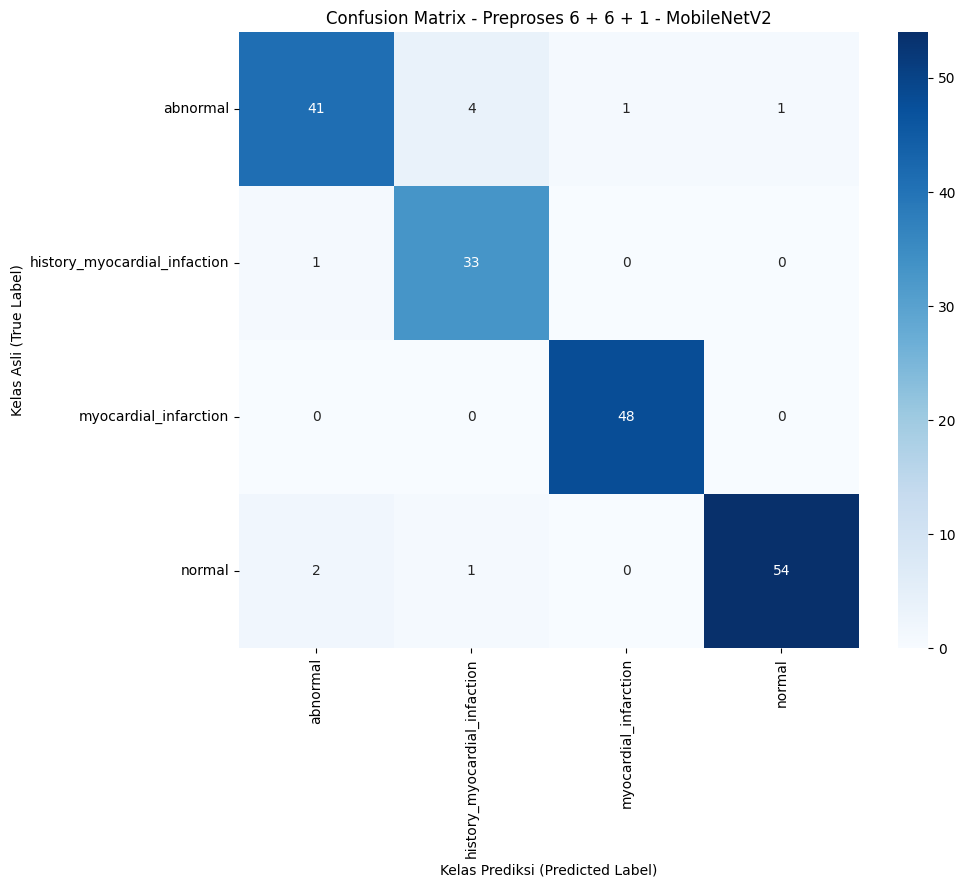

In [22]:
menampilkan_dan_menyimpan_confusion_matrix(cm, 'MobileNetV2')

## Evaluasi model dengan cara membuat classification report

In [23]:
def ubah_format_onehot(label):
    if label.ndim > 1:
        y_test_classes = np.argmax(label, axis=1)
    else:
        y_test_classes = y_test

    return y_test_classes

In [24]:
def generate_and_save_classification_report(y_true, y_pred, encoder, report_filename):
    try:
        # --- Persiapan Label ---
        # Jika y_true dalam format one-hot, ubah kembali ke format integer
        if y_true.ndim > 1 and y_true.shape[1] > 1:
            y_true_classes = np.argmax(y_true, axis=1)
        else:
            y_true_classes = y_true # Jika sudah integer

        # Dapatkan nama kelas dari encoder untuk pelabelan laporan
        target_names = encoder.classes_

        # --- Buat dan Cetak Laporan ---
        print("\nLaporan Klasifikasi (Classification Report):")
        print("======================================================")
        
        report = classification_report(y_true_classes, y_pred, target_names=target_names, digits=4)
        print(report)

        # --- Simpan laporan ke file .txt ---
        # Pastikan direktori ada (jika perlu)
        # folder_tujuan = os.path.dirname(report_filename)
        # os.makedirs(folder_tujuan, exist_ok=True)

        with open(report_filename, 'w') as f:
            f.write(f"Laporan Klasifikasi untuk Model\n")
            f.write("================================\n\n")
            f.write(report)
        
        print(f"\n✅ Laporan juga telah disimpan ke file: '{report_filename}'")
        
        return report

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan: {e}")
        return None

In [25]:
# Tentukan nama file laporan yang unik untuk setiap model
nama_file_laporan_mobilenet= 'classification_report_MobileNetV2_6plus6plus1.txt'

# Panggil fungsi untuk menghasilkan dan menyimpan laporan
laporan_resnet = generate_and_save_classification_report(
    y_true=y_test,
    y_pred=y_pred_classes,
    encoder=encoder,
    report_filename=nama_file_laporan_mobilenet
)


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.9318    0.8723    0.9011        47
history_myocardial_infaction     0.8684    0.9706    0.9167        34
       myocardial_infarction     0.9796    1.0000    0.9897        48
                      normal     0.9818    0.9474    0.9643        57

                    accuracy                         0.9462       186
                   macro avg     0.9404    0.9476    0.9429       186
                weighted avg     0.9479    0.9462    0.9462       186


✅ Laporan juga telah disimpan ke file: 'classification_report_MobileNetV2_6plus6plus1.txt'
